In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn import tree

In [2]:
#loading data
dataframe=pd.read_csv("insurance_pre.csv")

In [3]:
dataframe.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [4]:
#dataframe_processed=pd.get_dummies(dataframe, drop_first=True)
dataframe_processed = pd.get_dummies(dataframe, columns=['sex', 'smoker'], drop_first=True)

In [5]:
dataframe.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [6]:
dataframe_processed.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [7]:
independent=dataframe_processed[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]

In [8]:
independent.head()

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,False,True
1,18,33.770,1,True,False
2,28,33.000,3,True,False
3,33,22.705,0,True,False
4,32,28.880,0,True,False


In [9]:
dependent=dataframe_processed[['charges']]

In [10]:
dependent.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [11]:
#from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent,dependent,test_size=.3,random_state=0)

In [12]:
#from sklearn.tree import DecisionTreeRegressor
#regressor=DecisionTreeRegressor(criterion='squared_error', splitter='best', max_features=None)
#regressor=DecisionTreeRegressor(criterion='squared_error', splitter='best')
#criterion{“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}, default=”squared_error”
criterion1='squared_error'
#criterion1='absolute_error'
#criterion1='friedman_mse'
#criterion1='poisson'
######max_features int, float or {“sqrt”, “log2”}, default=None
max_features1=None
#max_features1=0.5
#max_features1='sqrt'
#max_features1='log2'
######3splitter{“best”, “random”}, default=”best”
splitter1='best'
#splitter1='random'
regressor=DecisionTreeRegressor(criterion=criterion1, splitter=splitter1, max_features=max_features1)
regressor=regressor.fit(X_train,y_train)

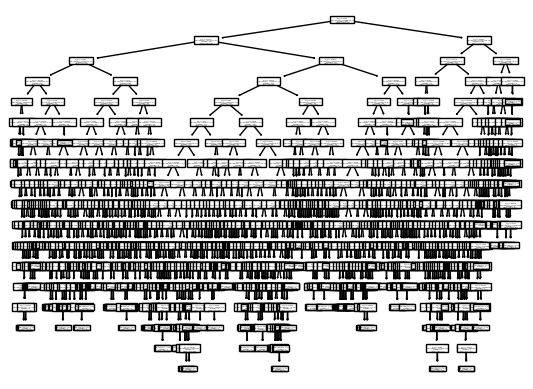

In [13]:
#import matplotlib.pyplot as plt
#from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [14]:
X_train.head()

,age,bmi,children,sex_male,smoker_yes
1163,18,28.215,0,False,False
196,39,32.800,0,False,False
438,52,46.750,5,False,False
183,44,26.410,0,False,False
1298,33,27.455,2,True,False


In [15]:
y_predict=regressor.predict(X_test)

In [16]:
from sklearn.metrics import r2_score

In [17]:
rscore=r2_score(y_test,y_predict)

In [18]:
rscore

0.7165670844105063

In [19]:
print(rscore,criterion1,max_features1, splitter1)

0.7165670844105063 squared_error None random


In [20]:
# import pickle
# pickle.dump(regressor,open("Wk3_Asgn_DecisionTree_001.sav","wb"))

In [21]:
# # Deploying saved model 
# loaded_model=pickle.load(open("Wk3_Asgn_DecisionTree_001.sav","rb"))

In [22]:
# #'age', 'bmi', 'children',  'sex_male', 'smoker_yes
# age_input=float(input("Age:"))
# bmi_input=float(input("Bmi: "))
# children_input=float(input("Number of Children: "))
# sex_input=int(input("Male 1 or Female 0: "))
# smoker_input=int(input("Smoker 1 or Non Smoker 0: "))

In [23]:
# result=loaded_model.predict([[age_input,bmi_input,children_input,sex_input,smoker_input]])

In [24]:
# result